In [1]:
import pandas as pd
from pandas import isnull

**Dataset #5**

In [2]:
e=pd.read_csv("iris.csv")
print(e)

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]


In [3]:
e.duplicated().sum()

np.int64(1)

In [4]:
e.drop_duplicates(inplace=True)

In [5]:
e.duplicated().sum()

np.int64(0)

In [6]:
e.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  149 non-null    float64
 1   sepal_width   149 non-null    float64
 2   petal_length  149 non-null    float64
 3   petal_width   149 non-null    float64
 4   species       149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [7]:
e.head(33)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [8]:
e.tail(2)

,sepal_length,sepal_width,petal_length,petal_width,species
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [9]:
e.shape

(149, 5)

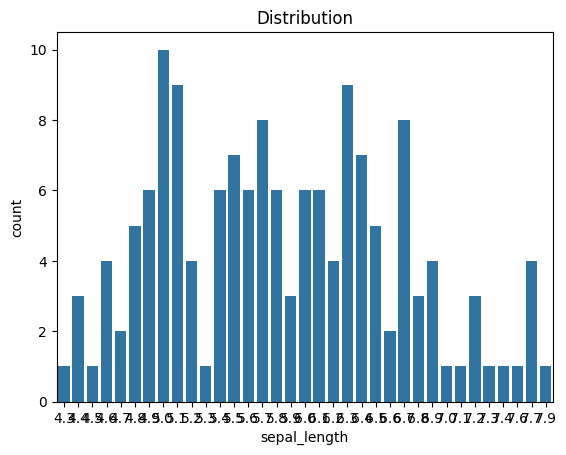

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sepal_length', data=e)
plt.title("Distribution")
plt.show()

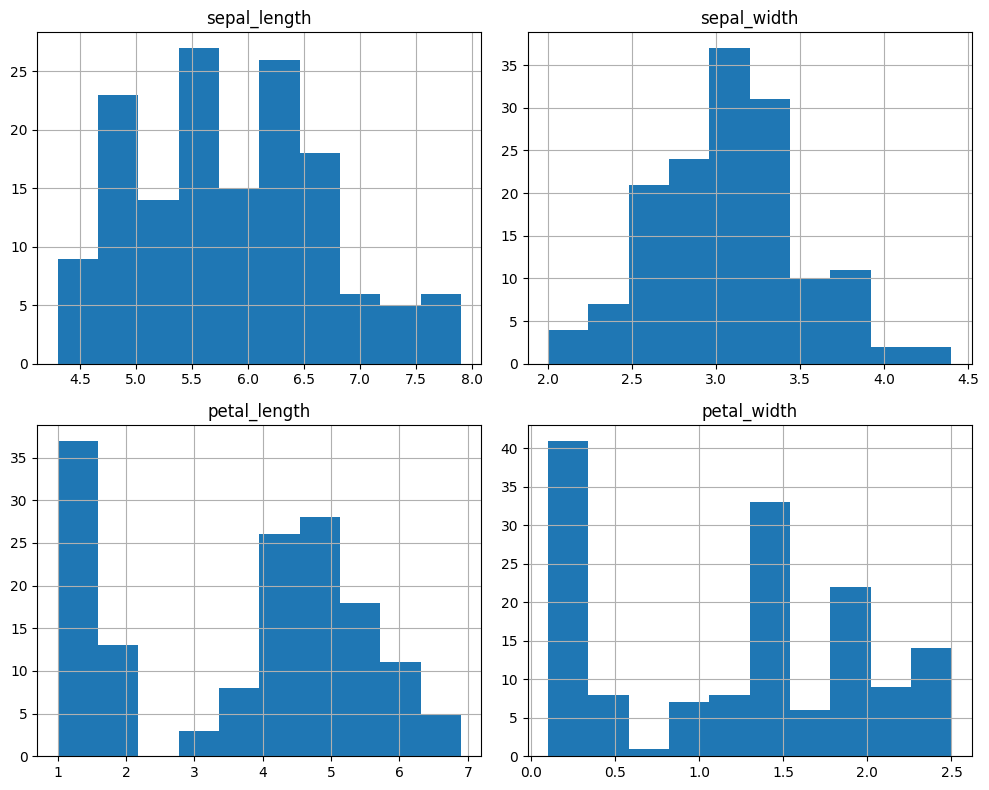

In [11]:
e.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

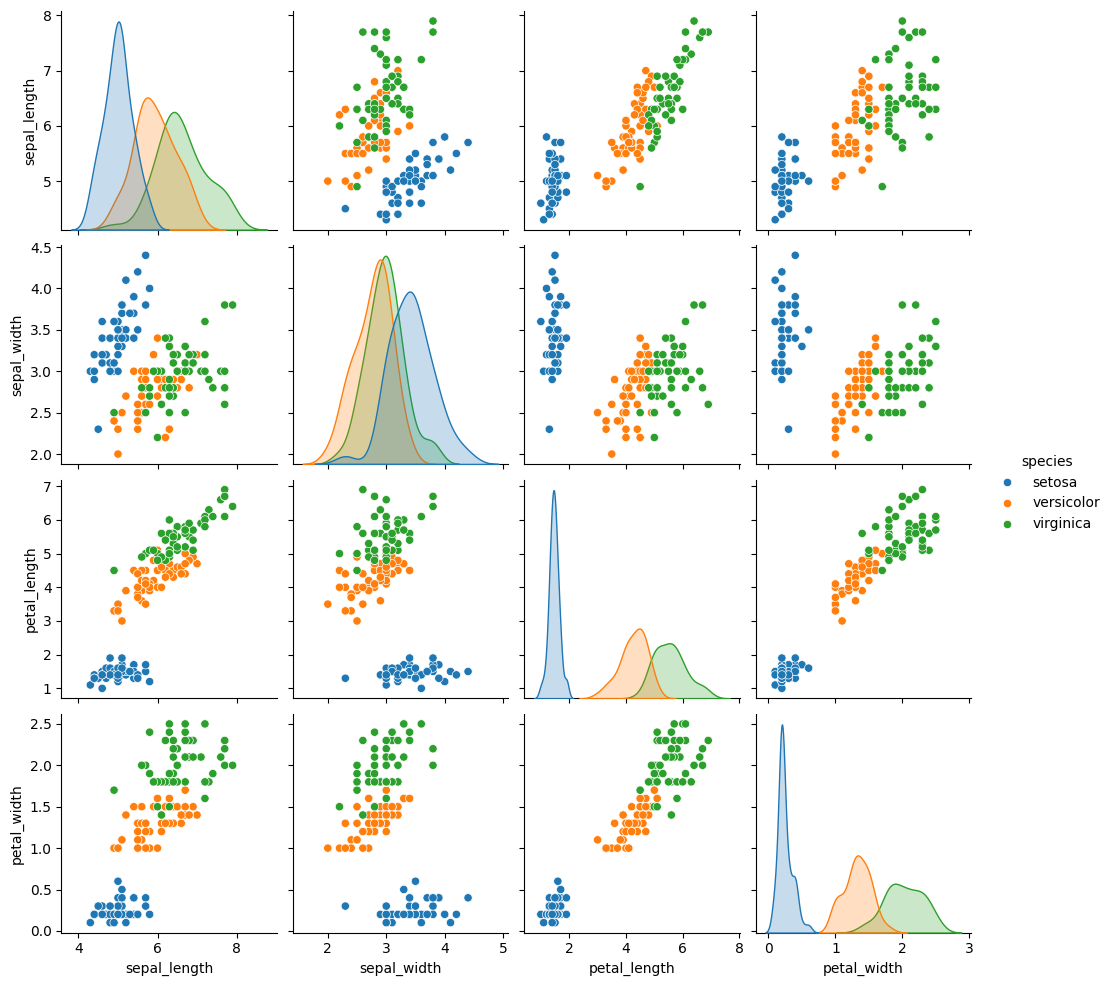

In [12]:
sns.pairplot(e, hue='species')
plt.show()

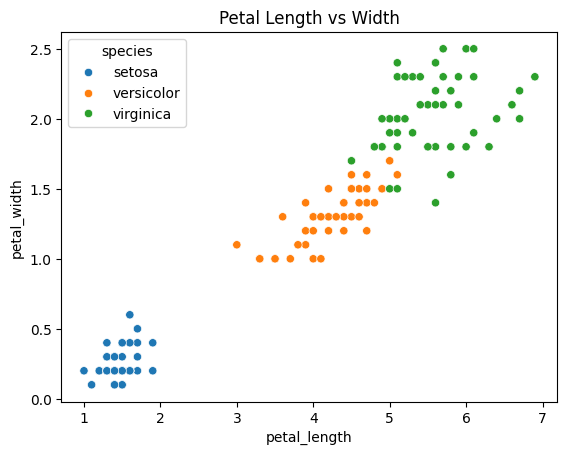

In [13]:
sns.scatterplot(x='petal_length', y='petal_width', hue='species', data=e)
plt.title("Petal Length vs Width")
plt.show()

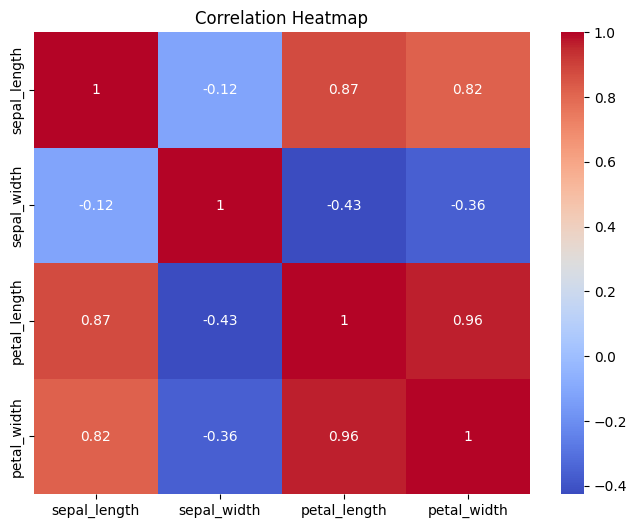

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(e.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [15]:
x=e.drop("species",axis=1)
y=e["species"]
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2)

In [16]:
print(xtrain.shape)
print(xtest.shape)
print(ytrain.shape)
print(ytest.shape)

(119, 4)
(30, 4)
(119,)
(30,)


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [18]:
# Impute missing values with the mean
imputer = SimpleImputer(strategy='mean') #impute module used to handle missing data. 'mean' specifies that missing values in the dataset should be replaced by the mean (average) value of the respective column.
x = imputer.fit_transform(x)

In [19]:
# Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.fit_transform(xtest)

In [20]:
print(xtrain)

[[-0.80429298  0.76794012 -1.3830638  -1.34470915]
 [ 0.17735691 -1.93309065  0.70542592  0.37309849]
 [-1.17241169 -0.13240347 -1.3830638  -1.34470915]
 [ 0.66818186 -0.35748937  0.29933069  0.10882039]
 [-1.04970546  0.99302602 -1.44107741 -1.2125701 ]
 [ 0.7908881  -0.13240347  0.99549393  0.76951564]
 [-1.04970546  0.31776833 -1.49909101 -1.34470915]
 [-0.92699922  0.54285422 -1.20902299 -0.948292  ]
 [ 2.26336294 -0.58257527  1.69165717  1.03379374]
 [ 0.42276939  0.76794012  0.93748033  1.43021089]
 [-0.1907618   1.66828371 -1.20902299 -1.2125701 ]
 [ 0.7908881  -0.58257527  0.4733715   0.37309849]
 [ 2.26336294  1.66828371  1.69165717  1.29807184]
 [ 0.42276939 -0.35748937  0.29933069  0.10882039]
 [-0.43617427  0.99302602 -1.44107741 -1.34470915]
 [-1.5405304   0.09268243 -1.3250502  -1.34470915]
 [-0.31346803 -1.25783296  0.06727628 -0.15545771]
 [ 0.54547562 -1.25783296  0.70542592  0.90165469]
 [-1.90864911 -0.13240347 -1.55710461 -1.4768482 ]
 [ 1.15900681 -0.58257527  0.58

In [21]:
print(xtest)

[[-1.13704653 -0.16018505 -1.16365763 -1.04852997]
 [ 0.11788777 -0.16018505  0.31065973  0.51773886]
 [-1.59338627  0.34566248 -1.21631182 -1.17905237]
 [-0.1102821  -1.17188012 -0.05791961 -0.13487315]
 [-1.3652164   1.35735754 -1.3742744  -1.17905237]
 [ 0.57422751 -0.66603258  0.78454745  0.51773886]
 [-1.25113146  0.34566248 -1.21631182 -1.17905237]
 [ 1.60099193  1.35735754  1.31108937  1.82296289]
 [-1.47930134 -1.93065141 -1.21631182 -1.04852997]
 [-1.02296159  0.09273871 -1.11100344 -1.30957477]
 [ 1.03056725  0.09273871  0.57393069  0.51773886]
 [ 0.57422751 -0.91895635  0.67923907  0.90930607]
 [ 1.03056725 -1.42480388  1.1531268   0.90930607]
 [-0.45253691  1.61028131 -1.11100344 -1.17905237]
 [ 0.00380283 -0.91895635  0.78454745  1.03982847]
 [ 0.46014257 -0.66603258  0.62658488  0.90930607]
 [ 0.34605764 -1.17188012  1.04781841  0.38721646]
 [ 0.80239738  0.34566248  0.78454745  1.17035088]
 [-0.79479172  1.10443378 -1.16365763 -1.17905237]
 [ 1.60099193  0.34566248  1.25

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [23]:
model = LogisticRegression()
model.fit(xtrain, ytrain)

LogisticRegression()

In [24]:
ypred = model.predict(xtest)

In [25]:
# Calculate accuracy
accuracy = accuracy_score(ytest, ypred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 93.33%


Text(0.5, 1.0, 'Confusion Matrix for Iris Types')

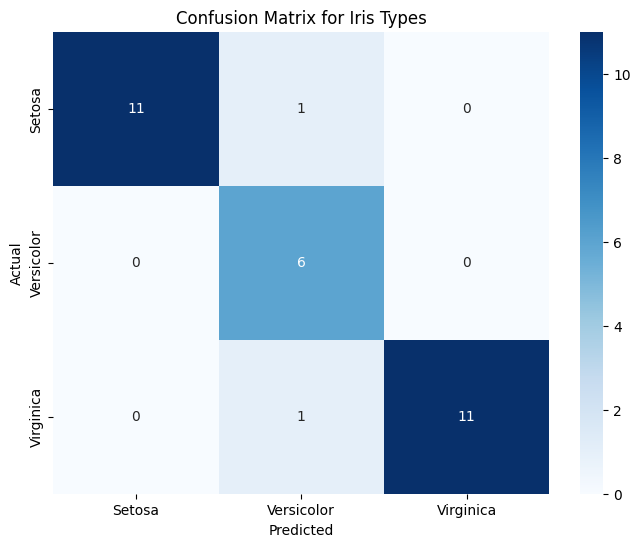

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(ytest, ypred)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Setosa', 'Versicolor', 'Virginica'], yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for Iris Types')

In [27]:
from sklearn.tree import DecisionTreeClassifier

In [28]:
model = DecisionTreeClassifier()
model.fit(xtrain, ytrain)

DecisionTreeClassifier()

In [29]:
y_pred = model.predict(xtest)

In [30]:
from sklearn.metrics import accuracy_score
print(accuracy_score(ytest, ypred))

0.9333333333333333


In [31]:
model = DecisionTreeClassifier(criterion='gini', max_depth=3)

model.fit(xtrain, ytrain)

DecisionTreeClassifier(max_depth=3)

In [32]:
predictions = model.predict(xtest)
accuracy = accuracy_score(ytest, predictions)
print(f'Accuracy: {accuracy * 100:.2f}')

Accuracy: 93.33


In [33]:
model = DecisionTreeClassifier(criterion='entropy', max_depth=30)

model.fit(xtrain, ytrain)

DecisionTreeClassifier(criterion='entropy', max_depth=30)

In [34]:
predictions = model.predict(xtest)
accuracy = accuracy_score(ytest, predictions)
print(f'Accuracy: {accuracy * 100:.2f}')

Accuracy: 96.67


In [35]:
model = DecisionTreeClassifier(criterion='log_loss', max_depth=10, min_samples_split = 25, min_samples_leaf = 50)

model.fit(xtrain, ytrain)

DecisionTreeClassifier(criterion='log_loss', max_depth=10, min_samples_leaf=50,
                       min_samples_split=25)

In [36]:
predictions = model.predict(xtest)
accuracy = accuracy_score(ytest, predictions)
print(f'Accuracy: {accuracy * 100:.2f}')

Accuracy: 80.00


In [37]:
from sklearn.metrics import accuracy_score

for crit in ['gini', 'entropy', 'log_loss']:
    model = DecisionTreeClassifier(criterion=crit)
    model.fit(xtrain, ytrain)
    ypred = model.predict(xtest)
    print(crit, accuracy_score(ytest, ypred))

gini 0.9666666666666667
entropy 0.9333333333333333
log_loss 0.9666666666666667


In [38]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    max_leaf_nodes=20,
    splitter='best',
    class_weight='balanced',
    random_state=42,
    ccp_alpha=0.01
)

In [39]:
model.fit(xtrain, ytrain)

DecisionTreeClassifier(ccp_alpha=0.01, class_weight='balanced',
                       criterion='entropy', max_depth=5, max_features='sqrt',
                       max_leaf_nodes=20, min_samples_leaf=5,
                       min_samples_split=10, random_state=42)

In [40]:
ypred = model.predict(xtest)
print(model.criterion, accuracy_score(ytest, ypred))

entropy 0.9333333333333333


In [41]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(xtrain, ytrain)

RandomForestClassifier()

In [42]:
ypred=model.predict(xtest)
print(accuracy_score(ytest,ypred))

0.9666666666666667


Text(0.5, 1.0, 'Confusion Matrix for Iris Types')

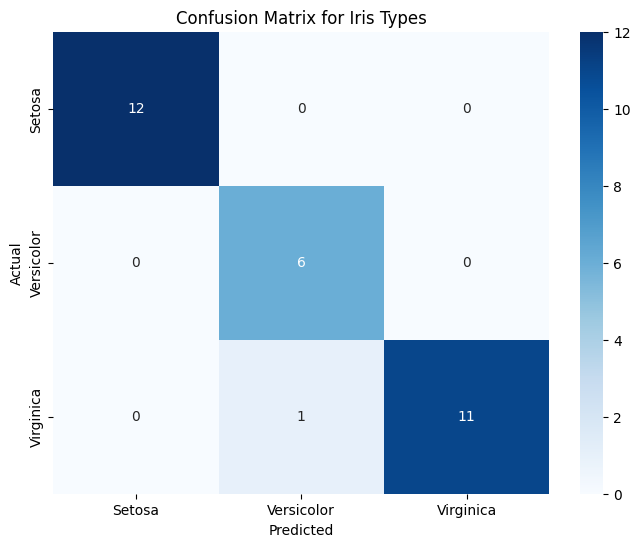

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(ytest, ypred)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Setosa', 'Versicolor', 'Virginica'], yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for Iris Types')

In [44]:
from sklearn.metrics import classification_report
ypred=model.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      1.00      0.92         6
   virginica       1.00      0.92      0.96        12

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



In [45]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=1000)
model.fit(xtrain, ytrain)

RandomForestClassifier(n_estimators=1000)

In [46]:
ypred=model.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      1.00      0.92         6
   virginica       1.00      0.92      0.96        12

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



In [47]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=5)
model.fit(xtrain, ytrain)

RandomForestClassifier(n_estimators=5)

In [48]:
ypred=model.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.75      1.00      0.86         6
   virginica       1.00      0.83      0.91        12

    accuracy                           0.93        30
   macro avg       0.92      0.94      0.92        30
weighted avg       0.95      0.93      0.94        30



In [49]:
from sklearn.svm import SVC

model = SVC(kernel = 'rbf')
model.fit(xtrain, ytrain)

SVC()

In [50]:
ypred=model.predict(xtest)
print(accuracy_score(ytest,ypred))

0.9333333333333333


Text(0.5, 1.0, 'Confusion Matrix for Iris Types')

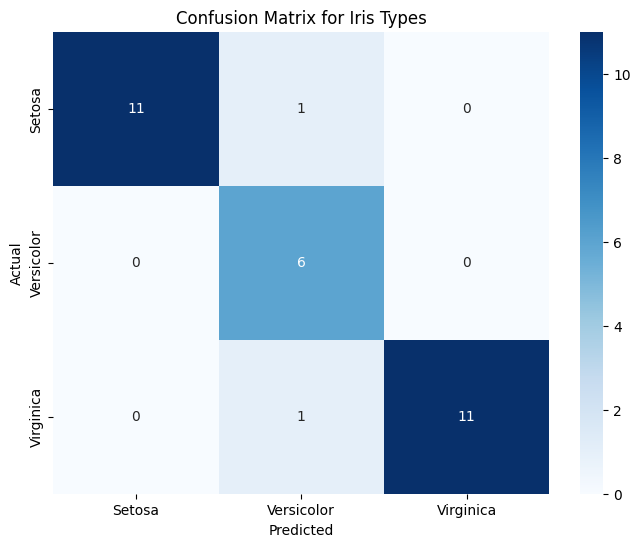

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(ytest, ypred)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Setosa', 'Versicolor', 'Virginica'], yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for Iris Types')

In [52]:
from sklearn.metrics import classification_report
ypred=model.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

      setosa       1.00      0.92      0.96        12
  versicolor       0.75      1.00      0.86         6
   virginica       1.00      0.92      0.96        12

    accuracy                           0.93        30
   macro avg       0.92      0.94      0.92        30
weighted avg       0.95      0.93      0.94        30



In [53]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(xtrain, ytrain)

GaussianNB()

In [54]:
ypred = model.predict(xtest)
print(accuracy_score(ytest,ypred))

0.9666666666666667


Text(0.5, 1.0, 'Confusion Matrix for Iris Types')

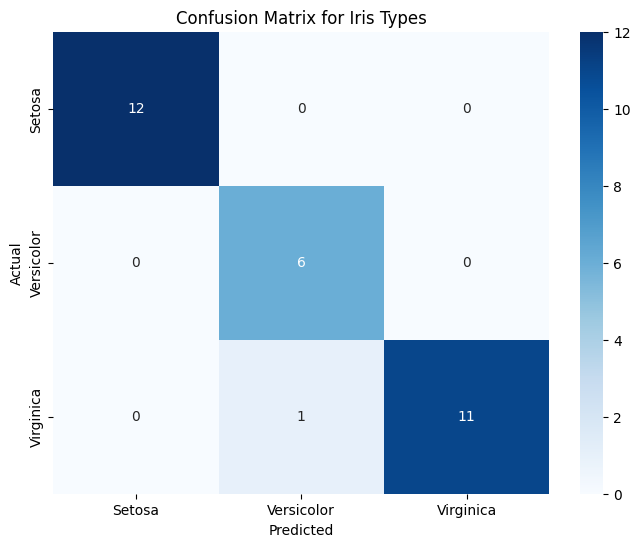

In [55]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(ytest, ypred)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Setosa', 'Versicolor', 'Virginica'], yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix for Iris Types')

In [56]:
from sklearn.metrics import classification_report
ypred=model.predict(xtest)
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      1.00      0.92         6
   virginica       1.00      0.92      0.96        12

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



In [57]:
model.predict_proba(xtest)

array([[1.00000000e+000, 2.35347265e-011, 6.54792768e-021],
       [1.14947633e-094, 9.87092630e-001, 1.29073702e-002],
       [1.00000000e+000, 1.54809875e-014, 5.48865969e-024],
       [1.40310162e-051, 9.99999065e-001, 9.35007434e-007],
       [1.00000000e+000, 1.75895510e-017, 1.25608312e-026],
       [2.60224076e-136, 5.50288052e-001, 4.49711948e-001],
       [1.00000000e+000, 2.54190527e-014, 8.51134734e-024],
       [2.78160675e-259, 4.61217361e-013, 1.00000000e+000],
       [1.00000000e+000, 1.02953198e-010, 5.09481414e-021],
       [1.00000000e+000, 2.56404500e-013, 7.64962971e-023],
       [2.38598371e-118, 6.04422872e-001, 3.95577128e-001],
       [2.47277764e-142, 3.53252252e-002, 9.64674775e-001],
       [6.30606379e-193, 2.48738111e-004, 9.99751262e-001],
       [1.00000000e+000, 3.36337625e-013, 6.27396945e-022],
       [3.01377016e-156, 5.71009045e-003, 9.94289910e-001],
       [6.06138659e-137, 5.24137666e-002, 9.47586233e-001],
       [1.01741683e-157, 4.71175841e-001

In [58]:
feature_names = e.drop('species', axis=1).columns
xtest_df = pd.DataFrame(xtest, columns=feature_names)
xtest_df['Predicted_Outcome'] = ypred
display(xtest_df.head())

,sepal_length,sepal_width,petal_length,petal_width,Predicted_Outcome
0,-1.137047,-0.160185,-1.163658,-1.048530,setosa
1,0.117888,-0.160185,0.310660,0.517739,versicolor
2,-1.593386,0.345662,-1.216312,-1.179052,setosa
3,-0.110282,-1.171880,-0.057920,-0.134873,versicolor
4,-1.365216,1.357358,-1.374274,-1.179052,setosa
